# **Introduction to Image Processing in Python**

Jesús David Petro Ramos - T00065696 \
Universidad Tecnológica de Bolívar

Link del repo donde he estado realizando la actividad: [Repo](https://github.com/JesusPetro/Vision-Artificial-2P2025/tree/main/semana%201)
<!-- Based on the jupyter notebook by [Vince Knight](https://github.com/drvinceknight/Python-Mathematics-Handbook) -->


### **Step 1: Cargamos las dependencias**

In [1]:
import numpy as np

import cv2
from skimage import io
from PIL import Image

import seaborn as sns
import matplotlib.pyplot as plt

### **TODO #1: Read an image from a URL, modify it and display it**

In [2]:
def modified_color_img(img): 
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))  # Display the image plot and define the subplot layout

    img_modified = img.copy()  # Create a copy of the original image
    img_modified[:100, :100] = [255, 0, 0]  # Change top-left corner to red

    ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Show the image after converting from BGR to RGB
    ax2.imshow(img_modified)

    ax1.set_title("Modified Image")
    ax1.axis("off")

    ax2.set_title("Modified Image, Original Colors")
    ax2.axis("off")

    plt.show()
    

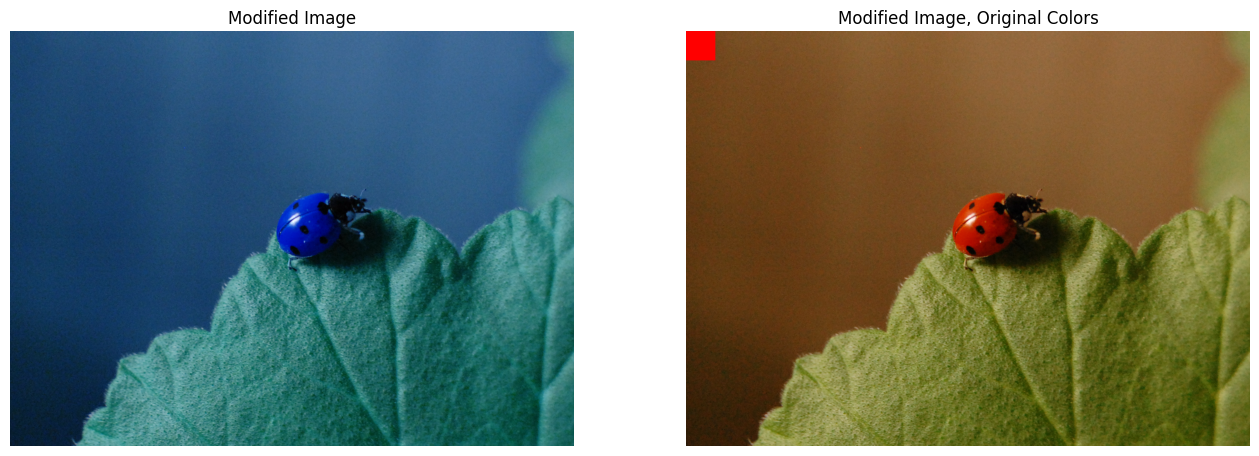

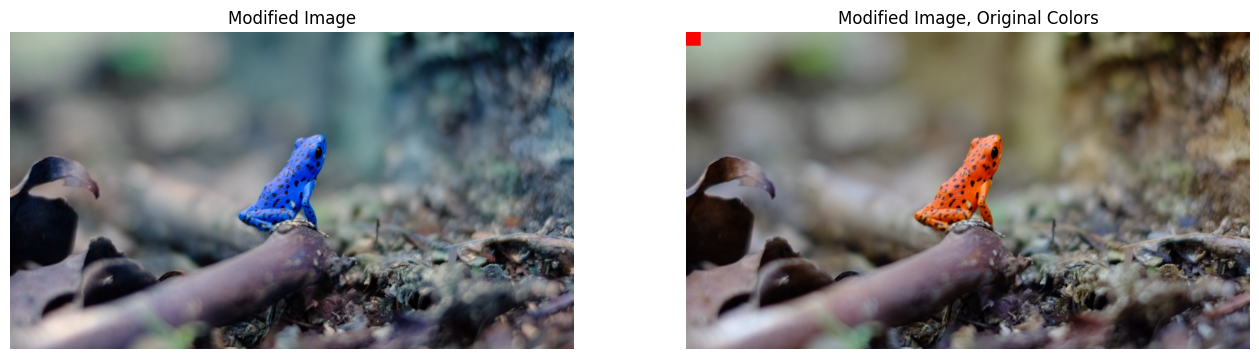

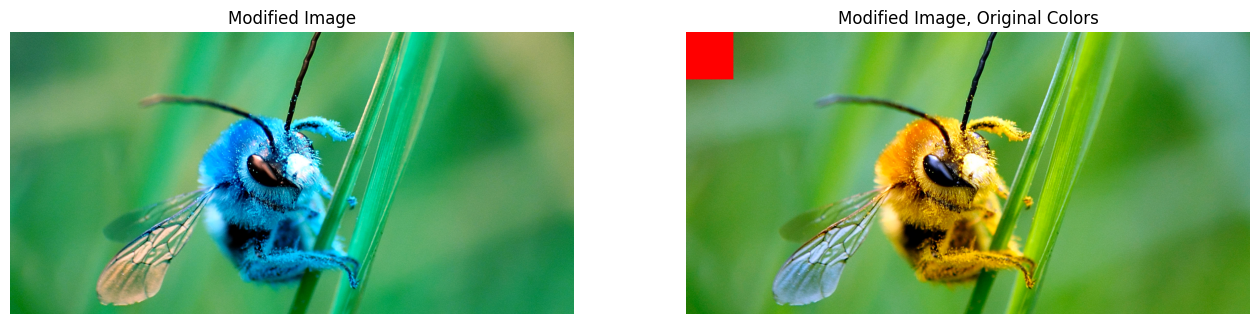

In [3]:
urls = [
    'https://jooinn.com/images/ladybug-9.jpg',  # ladybug
    'https://graffitiwallpaper.com/pics/listings/241_wide.jpg',  # orange frog
    'https://th.bing.com/th/id/R.ae33940a6035bee4aae3b0d5d64803cb?rik=elQ2Y5FUGRw9UA&riu=http%3a%2f%2fstatic2.businessinsider.com%2fimage%2f5736038bdd0895ef688b487a-1190-625%2fthis-mit-professor-is-using-bee-poop-to-map-an-invisible-world.jpg&ehk=HtHyGuq%2fs%2bW%2b1jZ%2btBPs5dm2dfZXFEjY%2fUslbIGTur8%3d&risl=&pid=ImgRaw&r=0'  # bee
]

imgs_urls = [io.imread(i) for i in urls]  # Create an array containing the images

# Display the images
for img in imgs_urls: 
    modified_color_img(img)


In [4]:
# Display the properties of each image
for idx, i in enumerate(imgs_urls):
    print(
        f'Image {idx+1}:'
        f'\nHeight: {i.shape[0]}, Width: {i.shape[1]}, Channels: {i.shape[2]}',
        end='\n\n'
    )


Image 1:
Height: 1412, Width: 1920, Channels: 3

Image 2:
Height: 2160, Width: 3840, Channels: 3

Image 3:
Height: 595, Width: 1190, Channels: 3



### **TODO # 2: DISPLAY THE GRAYSCALE OF YOUR COLOR IMAGE AND GENERATE HISTOGRAM**

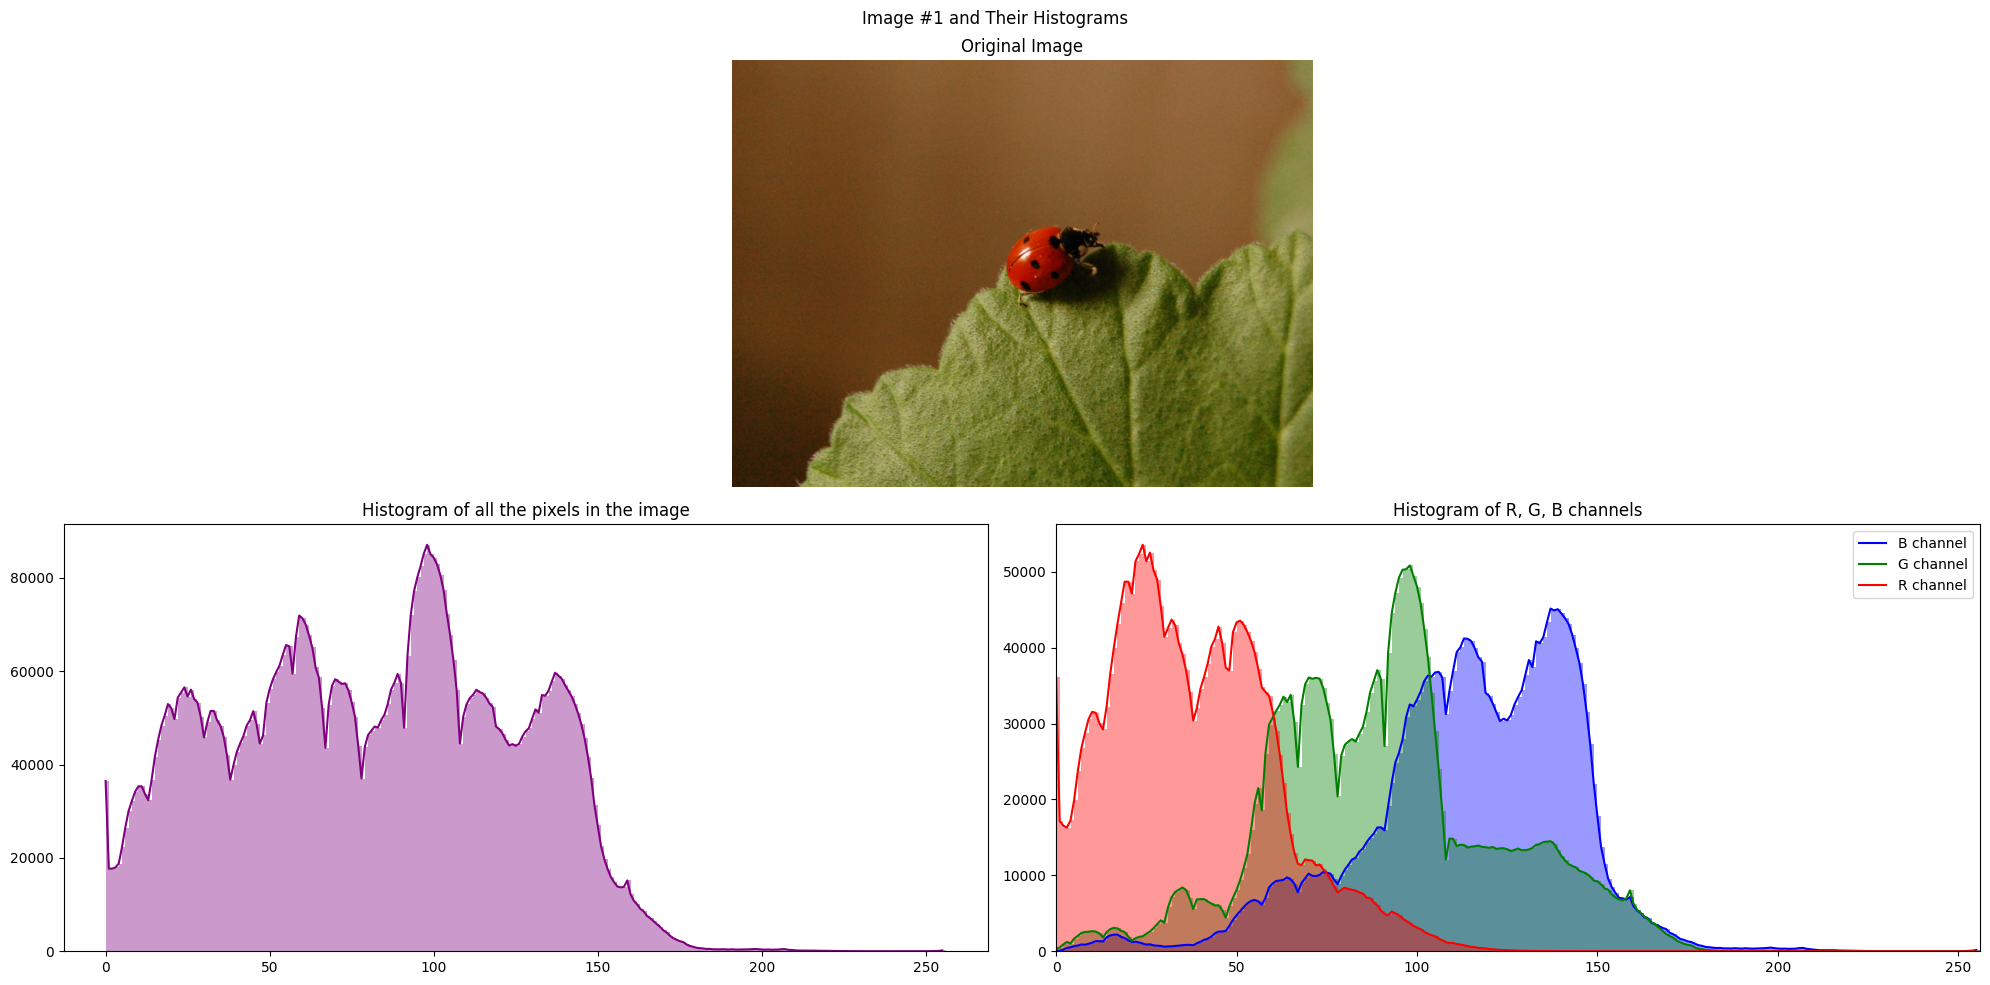

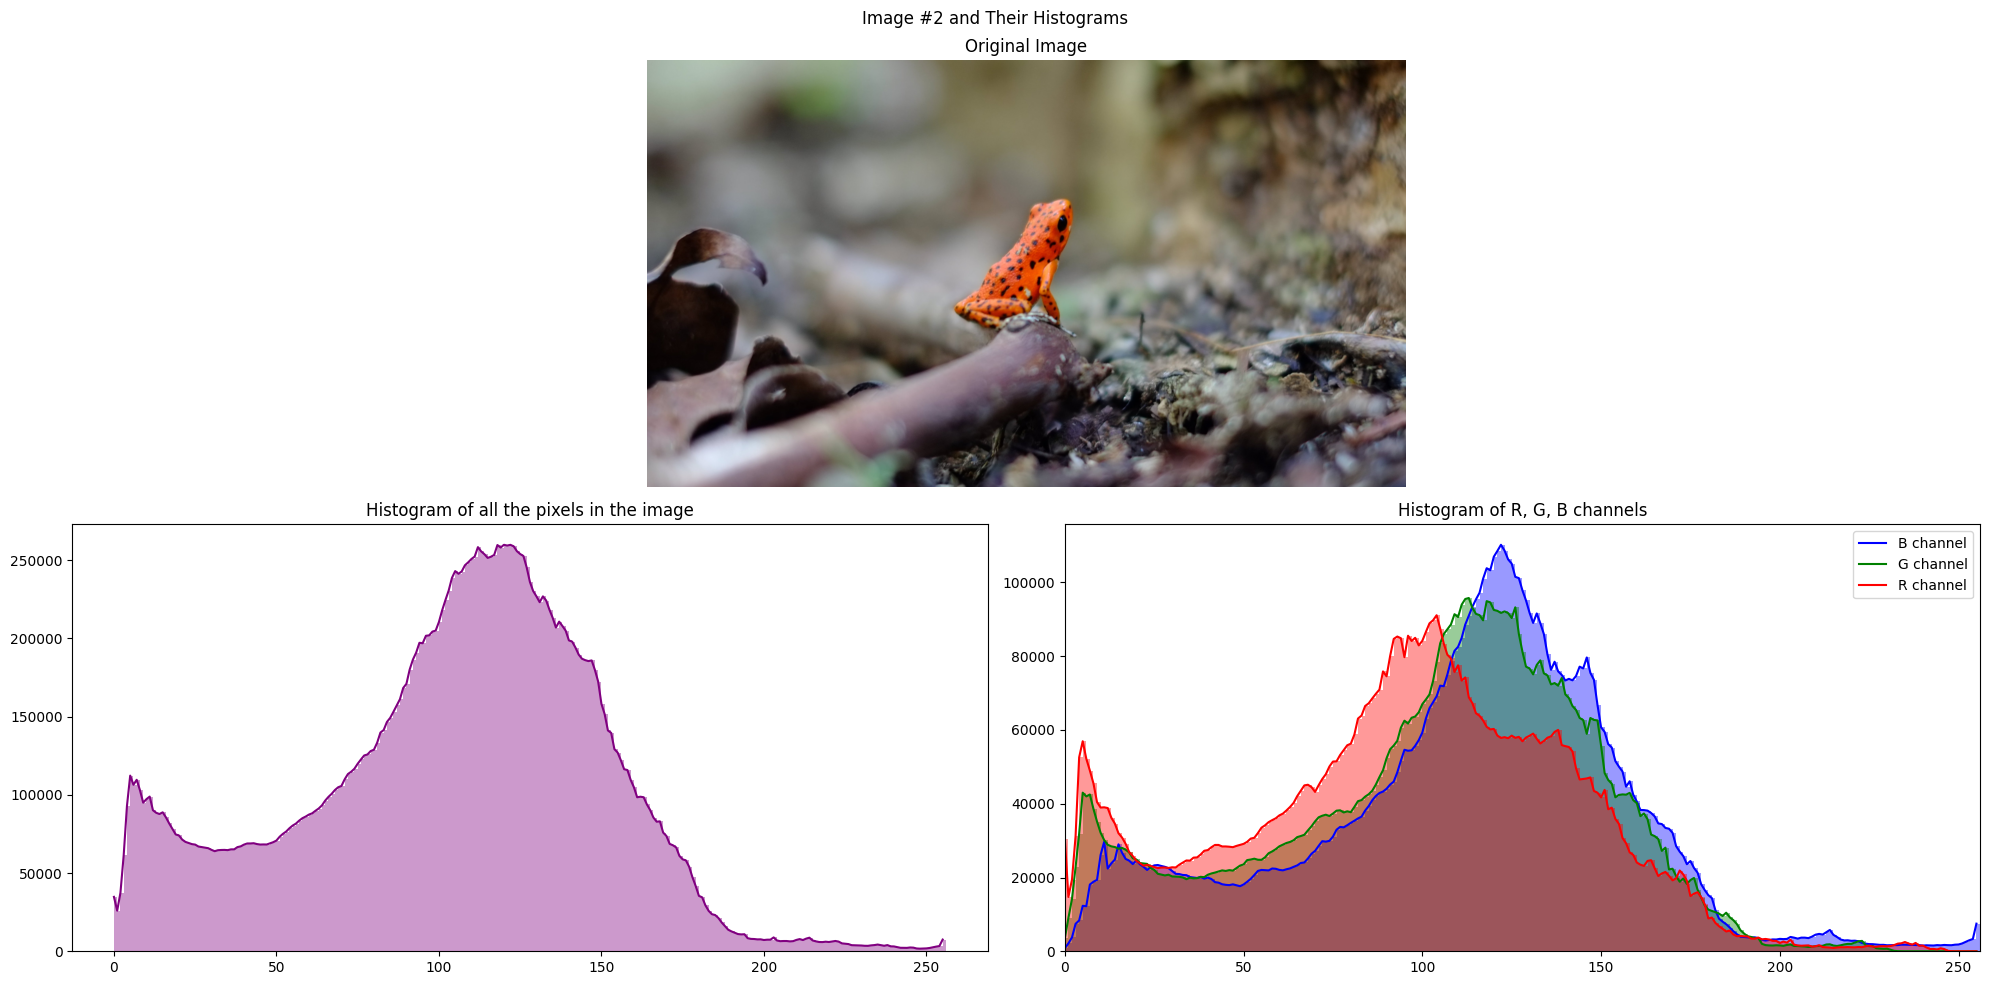

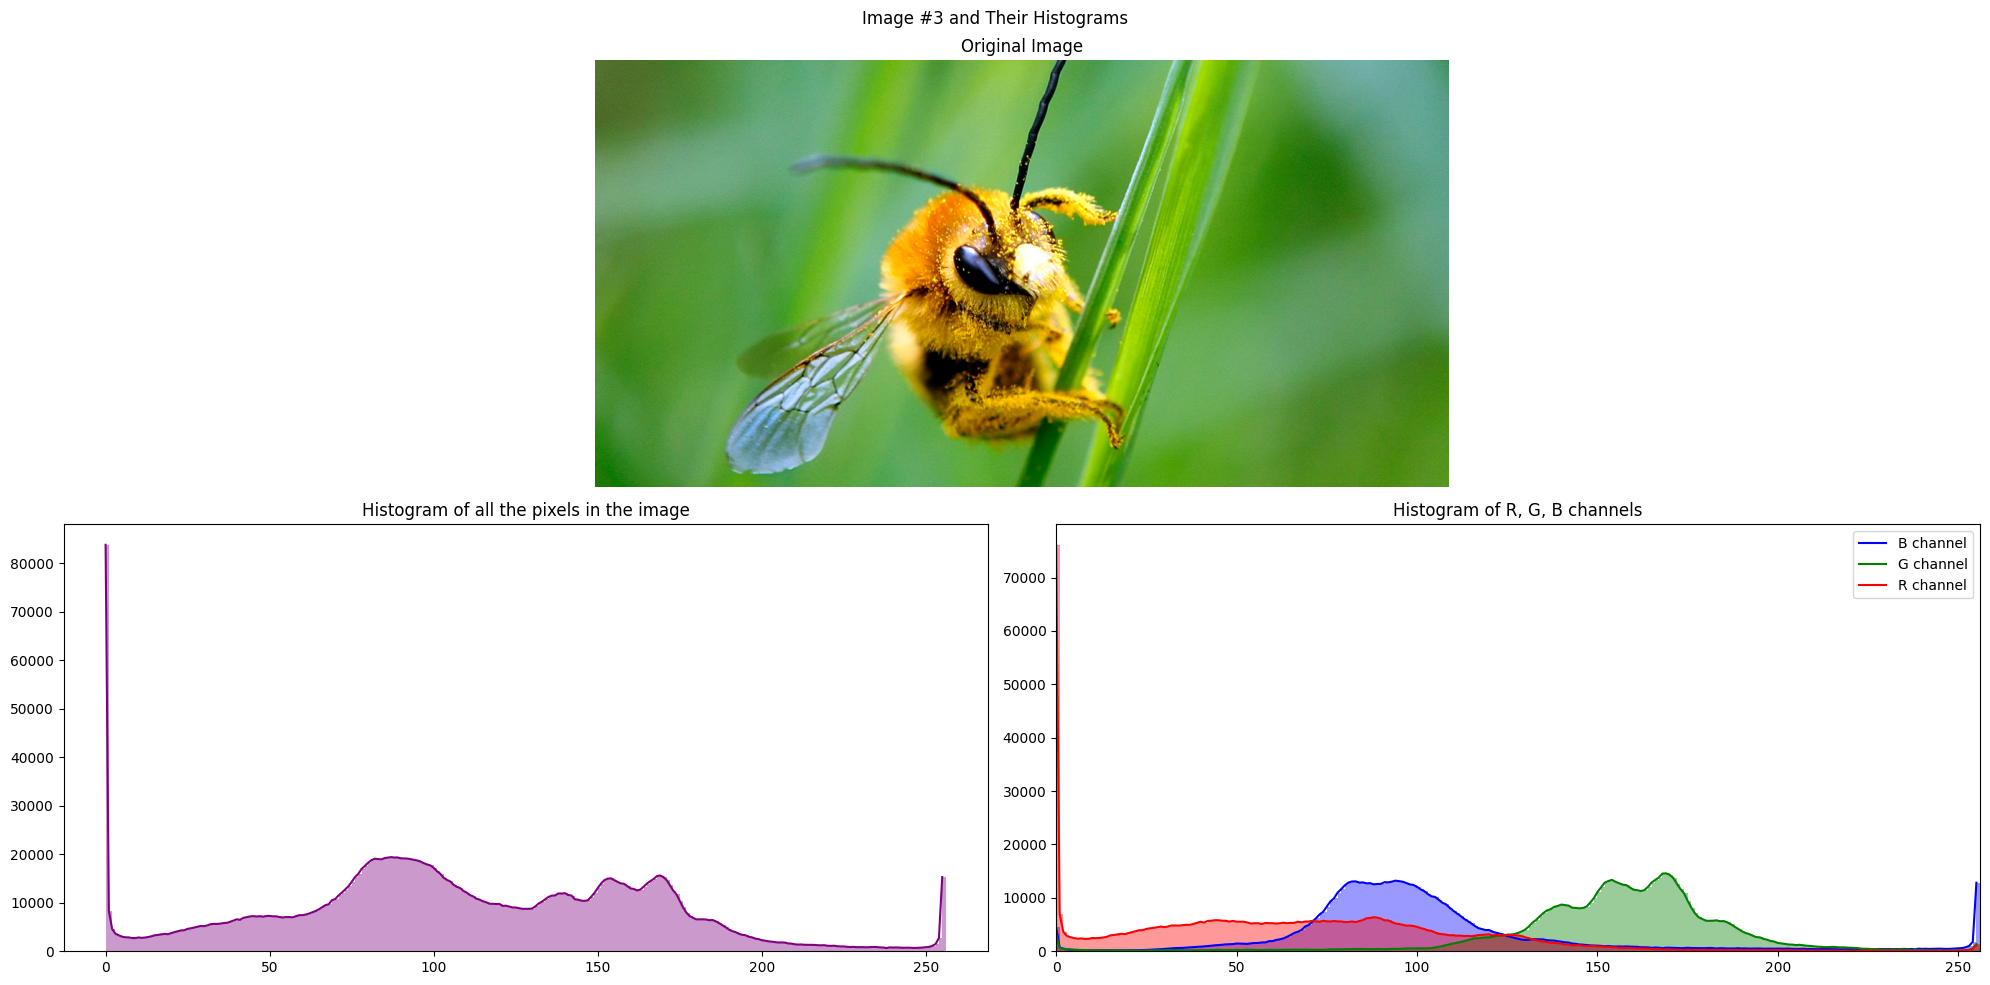

In [5]:
# First of all, generate the histogram for the original image (with BGR colors)

color = ('b', 'g', 'r')
for index, i in enumerate(imgs_urls):
    fig = plt.figure(figsize=(20, 10))

    # ax1: Display the original image (occupying the entire first row)
    ax1 = plt.subplot2grid((2, 2), (0, 0), colspan=2)
    ax1.set_title("Original Image")
    ax1.imshow(i)
    ax1.axis("off")  # Hide the axes for a cleaner look

    # ax2: Histogram of all pixels in the image (combined RGB channels)
    ax2 = plt.subplot2grid((2, 2), (1, 0))
    ax2.set_title("Histogram of all the pixels in the image")
    hist_values, bin_edges = np.histogram(i.ravel(), bins=256, range=[0, 256])

    
    ax2.hist(i.ravel(), bins=256, range=[0, 256], color='purple', alpha=0.4) # Plot histogram bars
    ax2.plot(bin_edges[:-1], hist_values, color='purple')  # Plot histogram line on top of the bars
    

    # ax3: Histogram of each RGB channel separately
    ax3 = plt.subplot2grid((2, 2), (1, 1))
    ax3.set_title("Histogram of R, G, B channels")
    for idx, col in enumerate(color):
        
        hist_values, bin_edges = np.histogram(i[:, :, idx].ravel(), bins=256, range=[0, 256]) # Calculate the histogram values without plotting
        
        ax3.hist(i[:, :, idx].ravel(), bins=256, range=[0, 256], color=col, alpha=0.4) # Plot the histogram as bars
        ax3.plot(bin_edges[:-1], hist_values, color=col, label=f"{col.upper()} channel") # Plot the histogram as a line on top of the bars
        ax3.set_xlim([0, 256]) # Set x-axis limits for consistency
        
    # Add legend for RGB channels
    ax3.legend()

    # Main title for the figure
    fig.suptitle(f'Image #{index+1} and Their Histograms')
    plt.tight_layout()
    plt.show()


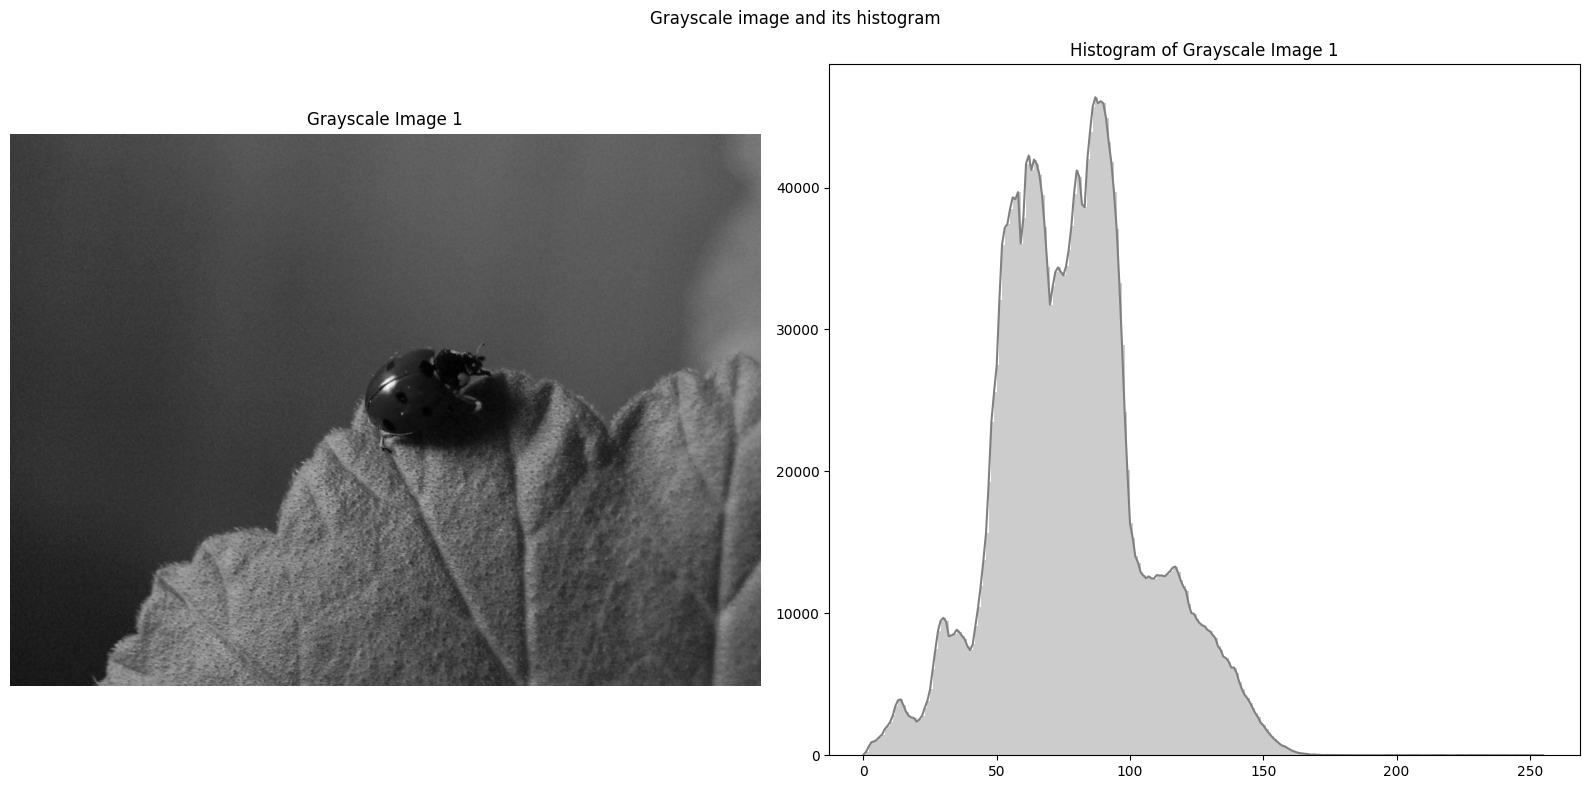

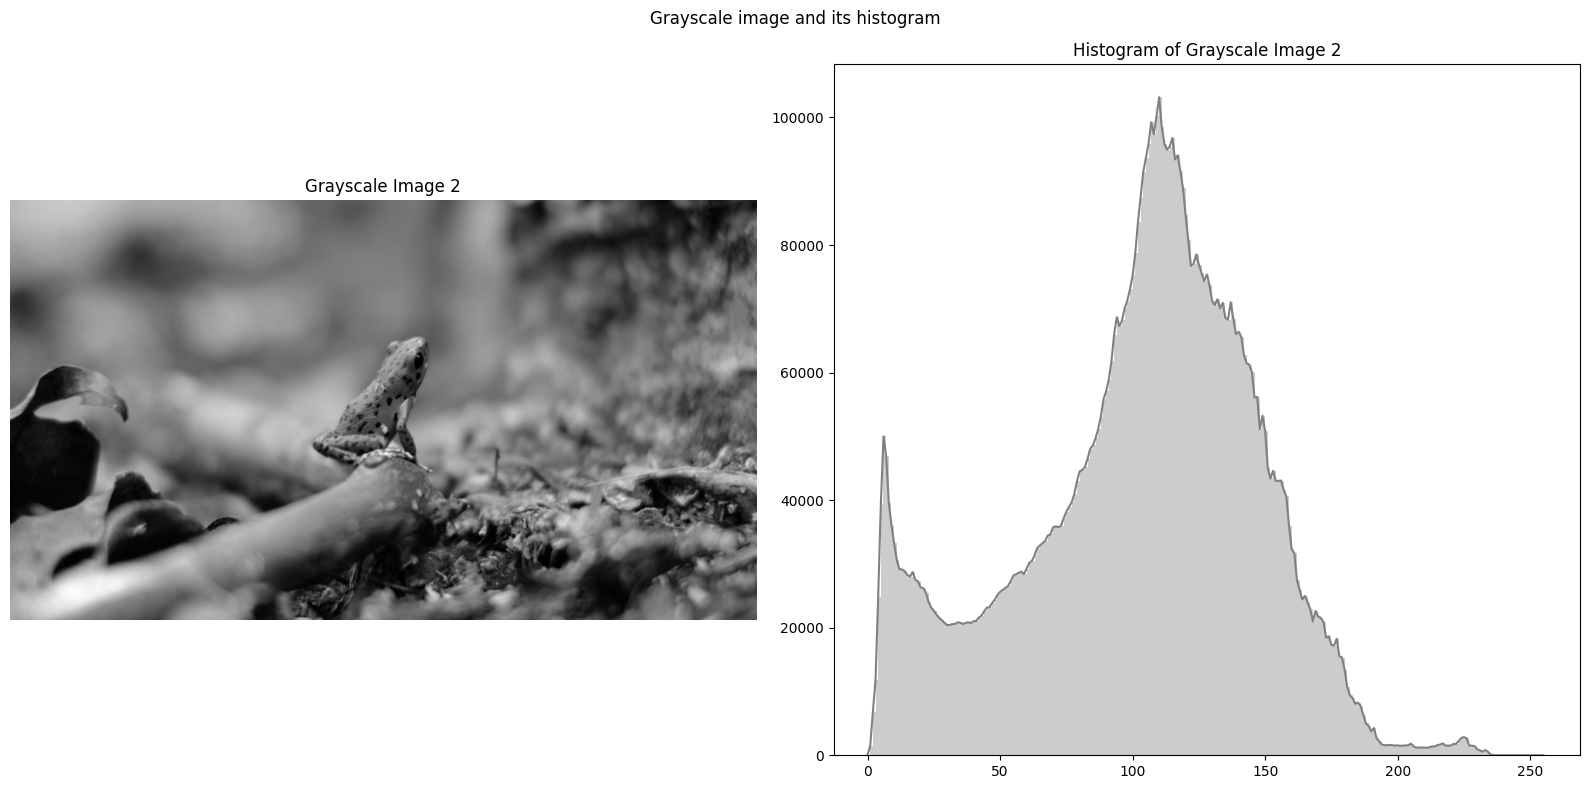

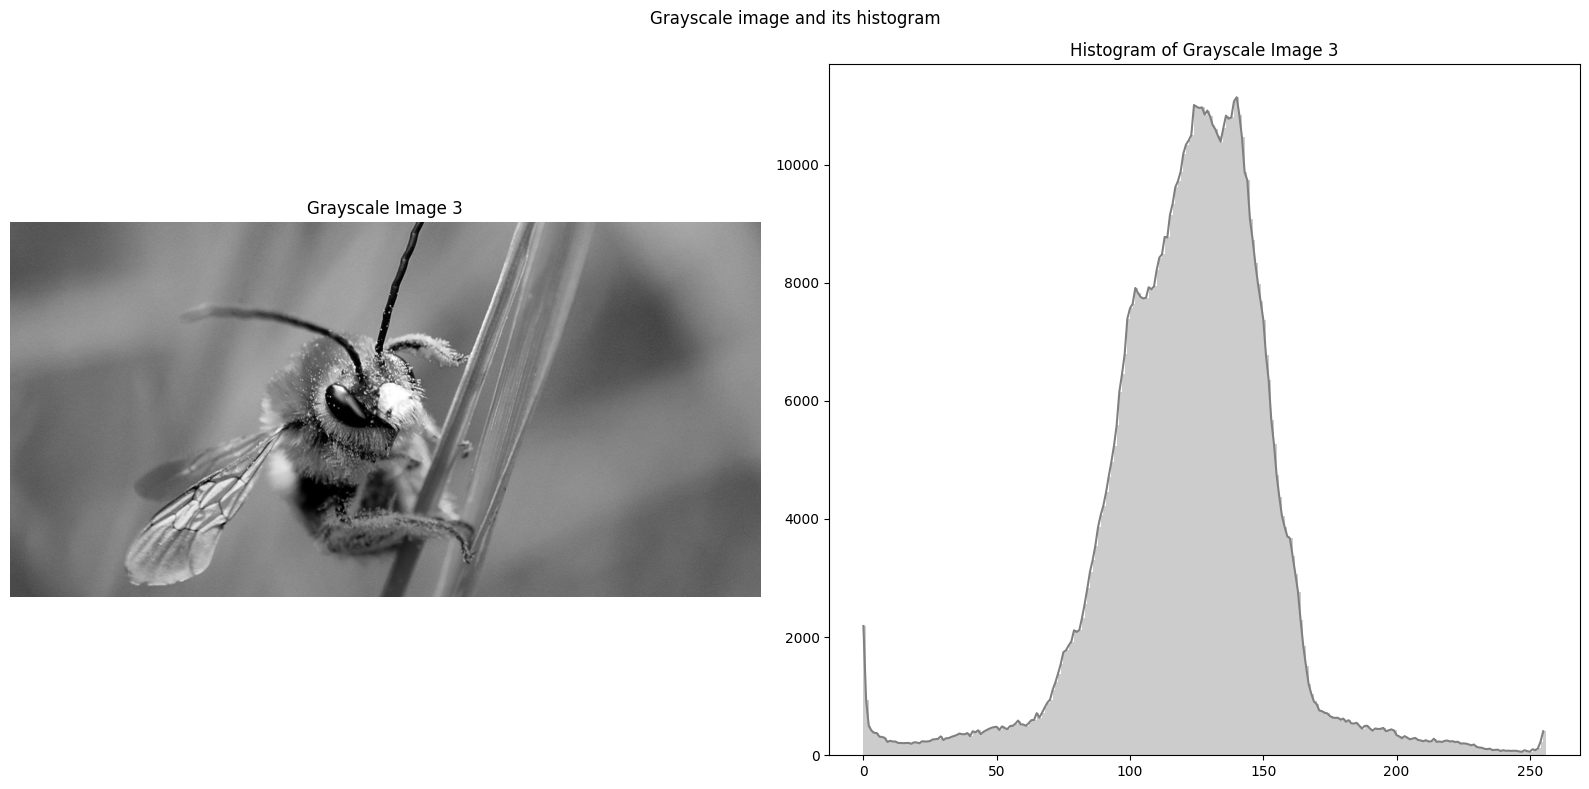

In [6]:
imgsGray = [cv2.cvtColor(i, cv2.COLOR_BGR2GRAY) for i in imgs_urls] # Convert to grayscale

for idx, i in enumerate(imgsGray):
    fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(16, 8))  # Display the image plot and define the subplot layout
    
    ax1.set_title(f"Grayscale Image {idx+1}")
    ax1.imshow(i, cmap='gray')
    ax1.axis('off')

    ax2.set_title(f"Histogram of Grayscale Image {idx+1}")

    hist_values, bin_edges = np.histogram(i.ravel(), bins=256, range=[0, 256])
    ax2.hist(i.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.4)
    ax2.plot(bin_edges[:-1], hist_values, color='gray')

    fig.suptitle('Grayscale image and its histogram')
    fig.tight_layout()
    plt.show()

### **TODO # 3: Find the contour of your own image**

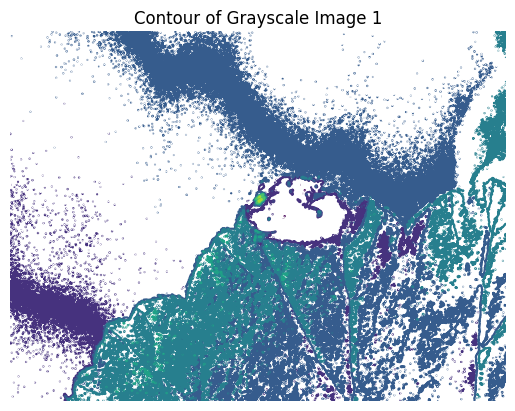

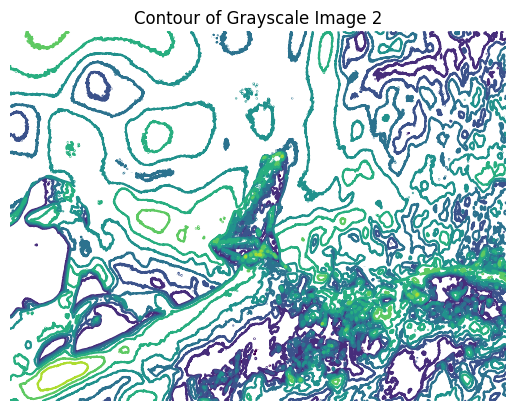

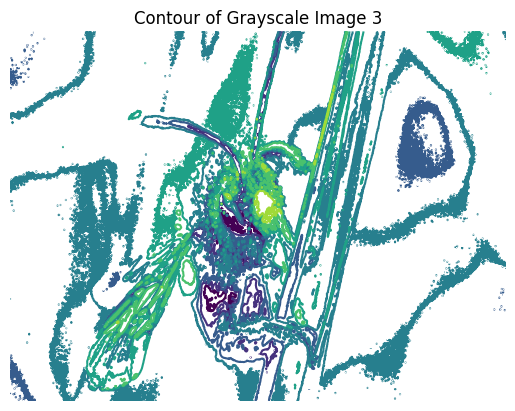

In [7]:
for idx, i in enumerate(imgsGray):
    plt.title(f'Contour of Grayscale Image {idx+1}')
    plt.contour(i, origin = 'image')  # Find and display the contour of the image
    plt.axis('off')
    plt.show()

### **TODO #4:  Try some mathematical operations on your image**


In [ ]:
# Source reference: https://www.tutorialspoint.com/dip/gray_level_transformations.htm
Transformation_GrayScale = {
    'Original': lambda img, **kwargs: img,  # Returns the original image without changes
    'Linear': lambda img, **kwargs: np.clip(kwargs['alpha'] * img + kwargs['beta'], 0, 255).astype(np.uint8),  # Adjusts contrast (alpha) and brightness (beta)
    'Negative': lambda img, **kwargs: 255 - img,  # Inverts pixel intensities (photographic negative)
    'Logarithmic': lambda img, **kwargs: kwargs['c_log'] * np.log(img + 1e-5 + 1),  # Enhances low intensities; +1e-5 avoids log(0)
    'Power': lambda img, **kwargs: kwargs['c_gamma'] * np.power(img, 1 / kwargs['gamma']),  # Gamma correction/Inverse Gamma (power-law transformation)
}


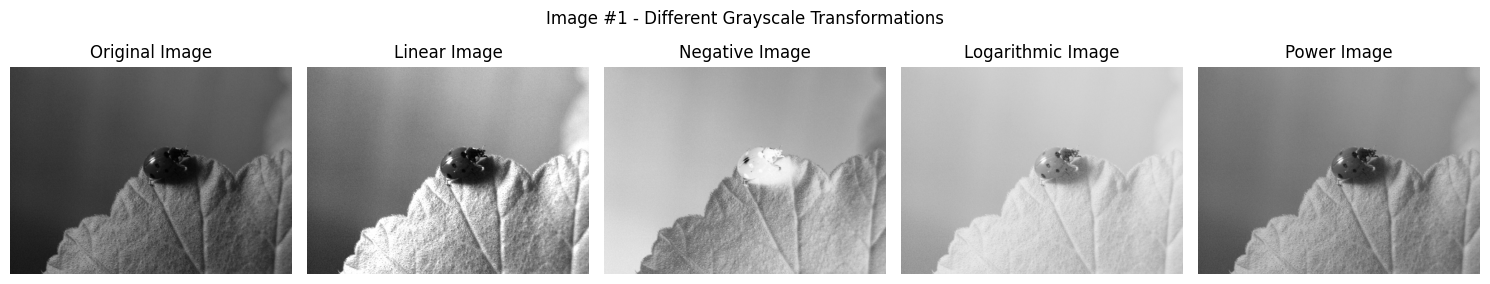

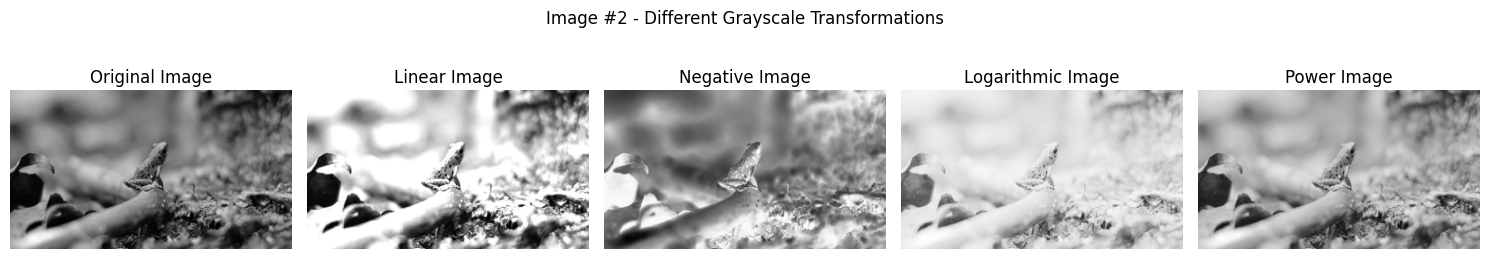

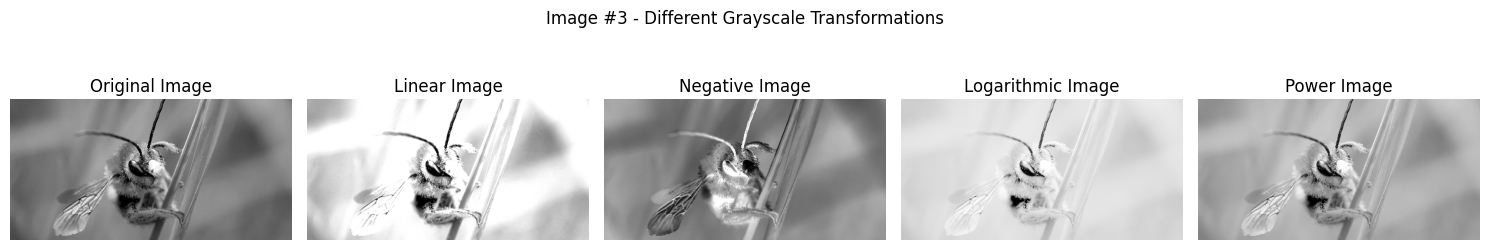

In [ ]:
# Values you can modify to test different transformation effects
kwargs = {
    'alpha': 1.7,   # Contrast factor for the linear transformation
    'beta': 30,     # Brightness adjustment for the linear transformation
    'c_log': 0.1,   # Constant for the logarithmic transformation
    'c_gamma': 1,   # Constant for the power-law (gamma) transformation
    'gamma': 1.85   # Gamma value for the power-law transformation
}

for idx, img in enumerate(imgsGray): 
    fig, axs = plt.subplots(1, 5, figsize=(15, 3))  # Create a figure with 1 row and 5 columns for the transformations
    
    fig.suptitle(f'Image #{idx+1} - Different Grayscale Transformations') 
    for (key, ax) in zip(Transformation_GrayScale.keys(), axs.flatten()): # Iterate over each transformation and corresponding subplot
        ax.set_title(f'{key} Image') 
        ax.imshow(Transformation_GrayScale[key](img, **kwargs), cmap='gray')  # Apply the transformation and display it
        ax.axis('off')

    fig.tight_layout()
    plt.show() 


### **TODO #5:  Other warping**

1. Choose a different set of source and destination coordinates to achieve a different perspective warp.
2. What happens when the destination points are moved closer together or further apart?